# Instructions

1. Review `Data Organization` and `Excel Scan Order Sheets` sections below.
2. Move script file to BASE_SOURCE_FOLDER.
3. Create new [projectName]_BIDS subdirectory in BASE_SOURCE_FOLDER if it does not already exist (e.g. `RAID_BIDS`).
4. Then run the script cell-by-cell on your Linux machine.
5. The last 2 cells include options for converting an entire directory vs a single participant. Run whichever you desire accordingly.

Questions can be directed to Ohad (ohad.dan@yale.edu) or Chelsea (chelsea.xu@yale.edu).

# Data Organization (of raw dicom files)

To successfully run, this script assumes that the source files are all organized under:

* BASE_SOURCE_FOLDER (e.g. `'/RAID/raw_dicom/'`)
* That folder, contain one folder per participant, named projectName_participantId (e.g. `RAID_10` for a project named RAID and participant 10)
* Each participant folder contains folders of scans, named projectName_participantId_scan[NUMBER]_someSuffix (e.g. `RAID_10_scan2_pc1079_levy` for the second scan), and excel sheets with the scan order for each scan, named projectName_participantID_scan[NUMBER]_order

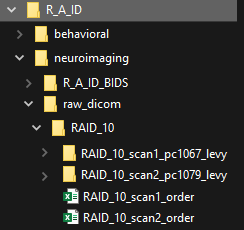

# Excel Scan Order Sheets

Excel sheets with scan order should contain 2 columns. The first colum should contain block number. Second column should contain task name (no spaces or underscores). Blocks of the same task should have a number after it (e.g. `gain1`, `gain2`). Aborted blocks should just be denoted by "aborted". See example below.

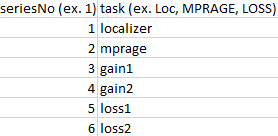

In [13]:
conda install -c conda-forge/label/cf201901 dcm2niix

Channels:
 - conda-forge/label/cf201901
 - conda-forge
 - bioconda
 - anaconda
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.7.1
    latest version: 25.9.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [14]:
!pip install openpyxl


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [15]:
import os
from nipype.interfaces.dcm2nii import Dcm2niix
import shutil
import pandas as pd

In [16]:
from pathlib import Path

In [17]:
os.chdir('/gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom')
os.getcwd()

'/gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom'

# Script constants


In [18]:
BASE_SOURCE_FOLDER = '/gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom'
PROJECT_NAME = os.getcwd().split('/')[-2]  ## Should extract the project name, e.g. 'RAID'
BASE_OUTPUT_FOLDER = os.path.dirname(os.getcwd()) + '/' + PROJECT_NAME + '_BIDS'
VERBOSE_MESSAGES = True

print(BASE_SOURCE_FOLDER)
print(PROJECT_NAME)
print(BASE_OUTPUT_FOLDER) #/gpfs/gibbs/pi/levy_ifat/Alex/valuation/neuroimaging/valuation_BIDS

/gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom
foodvaluation
/gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS


## Helper functions

In [19]:
def get_all_session_folder_names_for_participant(subName):
    '''
    Return all the session folder names for the input participants.
    For example, if a participant has sessions in the source folder named
    RAID_10_scan1_pc1067_levy and RAID_10_scan2_pc1079_levy, this function 
    will return the list with ['RAID_10_scan1_pc1067_levy', 'RAID_10_scan2_pc1079_levy']
    '''
    participant_path = os.path.join(BASE_SOURCE_FOLDER, PROJECT_NAME + '_' + str(subName))
    return next(os.walk(participant_path))[1]

def debug_message(message):
    if VERBOSE_MESSAGES:
        print('###' + message)
        
def create_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    
def participant_output_path(subName):
    return BASE_OUTPUT_FOLDER + '/' + 'sub-' + str(subName) + '/'

# Run the BIDS conversion
Documentation for the converter may be found [here](https://www.nitrc.org/plugins/mwiki/index.php/dcm2nii:MainPage#General_Usage) (e.g. what are the cryptic `%d, %a, %c`)

In [20]:
#%% Convert functions Converts DICOM to NIFTI.GZ
def convert_single_session(converter, subName, session_folder, session_number):
    '''
    Perform bids conversion for a single session of a single participant.
    converter:  Is a Dcm2niix object
    participant_number: is an integer which identifies the participant
    session_number: an integer representing a valid session of that participant
    '''
    converter = Dcm2niix()
    converter.inputs.source_dir = BASE_SOURCE_FOLDER + '/' + PROJECT_NAME + '_' + str(subName) + '/' + session_folder
    output_folder = participant_output_path(subName) + 'ses-' + str(session_number)
    if os.path.isdir(output_folder): #check if output folder exists
        debug_message('Folder ' + output_folder + ' already exists.')
        if os.listdir(output_folder): #check if output folder is empty
            debug_message('Folder ' + output_folder + ' already exists and is non-empty. Skipping conversion.')
            return #stop execution if folder has items    
    else: #otherwise make new output folder
        os.mkdir(output_folder)
    converter.inputs.output_dir = output_folder
    
    debug_message('Converting from: ' + converter.inputs.source_dir)
    debug_message('Converting to: ' + converter.inputs.output_dir)
    
    converter.inputs.out_filename = str(subName) + '%d' + '%a' + '%c' + '_' + '%2s' # %2s adds the scan block number
    ## 10_cmrr_mbep2d_bold(MB4iPAT2)a.nii.gz vs 10cmrr_mbep2d_bold(MB4iPAT2)HEA;HEPUnaliased_MB4_PE403.nii.gz
    
    converter.run()
    return output_folder
    
def convert_single_participant(subName, converter):
    participant_sessions = get_all_session_folder_names_for_participant(subName)
    for session_number,session_folder_name in enumerate(participant_sessions): # session numbers are enumerated sequentially from 0, 
                                                                            # we add 1 to output sessions starting from 1
        create_dir(participant_output_path(subName))
        output_folder = convert_single_session(converter, subName, session_folder_name, session_number+1)
    return participant_sessions, output_folder

In [21]:
def read_scan_blocks (sub_num, scan_num):
    """
    """
    sub_name = PROJECT_NAME + '_' + str(sub_num)
    scan_file = sub_name + '_scan' + str(scan_num) + '_order.xlsx'
    file_name = BASE_SOURCE_FOLDER + '/' + sub_name + '/' + scan_file
    dfs = pd.read_excel(file_name, sheet_name=None)
    return list(dfs['Sheet1'].iloc[:,1])


read_scan_blocks('030',1)

['localizer', 'MPRAGE', 'rating', 'learning', 'learning']

In [22]:
# for a single subject, convert

subName = '030'  # Participant number as integer

# When converting the participant, format the 'subName' with leading zeros dynamically
#formatted_subName = f"{subName:03}"  # Formats the number as a string with leading zeros, e.g., '003'

participant_sessions = convert_single_participant(subName, Dcm2niix())

###Converting from: /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom/foodvaluation_030/foodvaluation_030_scan1_vd568_levy
###Converting to: /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1
251007-13:23:13,881 nipype.interface INFO:
	 stdout 2025-10-07T13:23:13.881303:Compression will be faster with 'pigz' installed
251007-13:23:13,882 nipype.interface INFO:
	 stdout 2025-10-07T13:23:13.881303:Chris Rorden's dcm2niiX version v1.0.20181114  GCC4.8.2 (64-bit Linux)
251007-13:23:13,882 nipype.interface INFO:
	 stdout 2025-10-07T13:23:13.881303:Found 2427 DICOM file(s)
251007-13:23:13,882 nipype.interface INFO:
	 stdout 2025-10-07T13:23:13.881303:slice orientation varies (localizer?) [0 1 0 0 0 -1] != [1 0 0 0 0 -1]
251007-13:23:13,883 nipype.interface INFO:
	 stdout 2025-10-07T13:23:13.881303:Warning: interpolated protocol 'localizer' may be unsuitable for dwidenoise/mrdegibbs. /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/raw_dicom/foodvaluation_030/foodvalu

# Organize conversion output to BIDS folder structure
write function organize_directory to organize to BIDS format
* __anat/__ - Anatomical holds the blocks: _mprage_, _flash_, _T2w_
* __func/__ - Functional holds the task blocks
* __dwi/__ - Diffusion weighted imaging
* __misc/__ - Miscellaneous holds the blocks: _localizer_

In [23]:
import os
import pandas as pd
import shutil
import gzip

def file_suffix(file_name):
    if file_name.endswith('.json'):
        return '.json'
    elif file_name.endswith('.nii.gz'):
        return '.nii.gz'
    elif file_name.endswith('.bvec'):
        return '.bvec'
    elif file_name.endswith('.bval'):
        return '.bval'
    elif file_name.endswith('.nii'):  # support for .nii, but you will want to gzip the .nii learning task file either before or after this!
        return '.nii'

def gzip_nii_file(nii_file_path):
    with open(nii_file_path, 'rb') as f:
        with gzip.open(nii_file_path + '.gz', 'wb') as f_out:
            shutil.copyfileobj(f, f_out)
    os.remove(nii_file_path)  # Removes the original .nii file after compression
    return nii_file_path + '.gz'

def get_all_files_in_dir(output_folder):
    return next(os.walk(output_folder))[2]

def get_file_subdir(file_name):
    if 'T1w' in file_name:
        return 'anat'
    elif 'localizer' in file_name:
        return 'misc'
    elif 'aborted' in file_name:
        return 'misc'
    elif 'bold' in file_name and 'task' in file_name:
        return 'func'
    elif 'bold' in file_name:
        return 'func'
    elif 'T2w' in file_name:
        return 'anat'
    elif 'dwi' in file_name:
        return 'dwi'
    else:
        return 'misc'

def read_scan_blocks(sub_num, scan_num):
    sub_name = PROJECT_NAME + '_' + str(sub_num)
    scan_file = sub_name + '_scan' + str(scan_num) + '_order.xlsx'
    file_name = BASE_SOURCE_FOLDER + '/' + sub_name + '/' + scan_file
    dfs = pd.read_excel(file_name, sheet_name=None)
    return list(dfs['Sheet1'].iloc[:, 1])

def get_file_new_name(subName, session, file_name):
    if 'localizer' in file_name: 
        localizer_run_number = int(''.join(filter(str.isdigit, file_name.split('.')[0][-2:])))
        return f'sub-{subName}_ses-{session}_localizer_run-{localizer_run_number}{file_suffix(file_name)}'
    elif 'MPR' in file_name:  # Check for 'MPR' in place of 'MPRAGE' as well
        return f'sub-{subName}_ses-{session}_acq-mprage_T1w{file_suffix(file_name)}'
    elif 'diff' in file_name:
        return f'sub-{subName}_ses-{session}_dwi{file_suffix(file_name)}'
    elif 't1_flash' in file_name:
        return f'sub-{subName}_ses-{session}_acq-FLASH_T1w{file_suffix(file_name)}'
    elif 't2' in file_name:
        return f'sub-{subName}_ses-{session}_T2w{file_suffix(file_name)}'
    else:
        # Check if the last part of the filename contains only digits
        last_part = file_name.split('.')[0].split('_')[-1]
        if last_part.isdigit():
            idx = int(last_part) - 1  # Corrected to match 0-based index with 1-based tasks
            blocks = read_scan_blocks(subName, session)  # From Excel sheet 
            return f'sub-{subName}_ses-{session}_task-{blocks[idx]}_bold{file_suffix(file_name)}'
        else:
            # Files that have non-numeric suffixes like 03a, 04a, etc.
            return None

def move_and_rename(file_name, file_target_subdirectory, file_new_name):
    shutil.move(file_name, file_target_subdirectory + '/' + file_new_name)

# Organize function with additional filtering
def organizeFiles(output_folder, subName, session):
    all_files = get_all_files_in_dir(output_folder)
    for file_name in all_files:
        file_path = os.path.join(output_folder, file_name)
        file_target_subdirectory = 'misc'

        size = os.path.getsize(file_path)
        file_new_name = get_file_new_name(subName, session, file_name)

        # Apply size limit only to functional (BOLD) .nii.gz files
        if file_new_name and ('bold' in file_new_name and file_name.endswith('.nii.gz') and size < 800000):
            file_target_subdirectory = 'misc'
        elif file_new_name:
            file_target_subdirectory = get_file_subdir(file_new_name)
            
        target_dir_path = os.path.join(output_folder, file_target_subdirectory)
        if not os.path.exists(target_dir_path):
            os.makedirs(target_dir_path)
        print(f"Moving {file_name} to {os.path.join(target_dir_path, file_new_name if file_new_name else file_name)}")
        move_and_rename(file_path, target_dir_path, file_new_name if file_new_name else file_name)

In [24]:
# after conversion: for a single subject, gzip the learning task file and then rename/organize into BIDS format

subName = '030'  # Replace participant number e.g. "subName = 10"

for session_number in range(len(participant_sessions)):
    session = session_number + 1
    output_folder = BASE_OUTPUT_FOLDER + '/' + 'sub-' + str(subName) + '/' + 'ses-' + str(session)
    
    # Gzip .nii files before organizing
    all_files = get_all_files_in_dir(output_folder)
    for file_name in all_files:
        file_path = os.path.join(output_folder, file_name)
        if file_name.endswith('.nii') and 'bold_task' in file_name:  # Adjust condition if necessary
            gzip_nii_file(file_path)
            
    organizeFiles(output_folder, subName, session)

Moving 030cmrr_mbep2d_bold_task(MB4iPAT2)HeadNeck_20_TCSNot_for_diagnostic_use_Unaliased_MB4_PE4_03.nii.gz to /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1/func/sub-030_ses-1_task-rating_bold.nii.gz
Moving 030cmrr_mbep2d_bold_task(MB4iPAT2)HeadNeck_20_TCSNot_for_diagnostic_use_Unaliased_MB4_PE4_05.nii.gz to /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1/func/sub-030_ses-1_task-learning_bold.nii.gz
Moving 030localizerHeadNeck_20_TCS_01.json to /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1/misc/sub-030_ses-1_localizer_run-1.json
Moving 030cmrr_mbep2d_bold_task(MB4iPAT2)HeadNeck_20_TCSNot_for_diagnostic_use_Unaliased_MB4_PE4_05.json to /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1/func/sub-030_ses-1_task-learning_bold.json
Moving 030T1W_MPR_1mmHeadNeck_20_TCS_02.json to /gpfs/gibbs/pi/levy_ifat/Alex/foodvaluation/foodvaluation_BIDS/sub-030/ses-1/anat/sub-030_ses-1_acq

StopIteration: 